X_train shape: (3200, 29)
X_test shape: (800, 29)
Accuracy Decision Tree: 0.89375


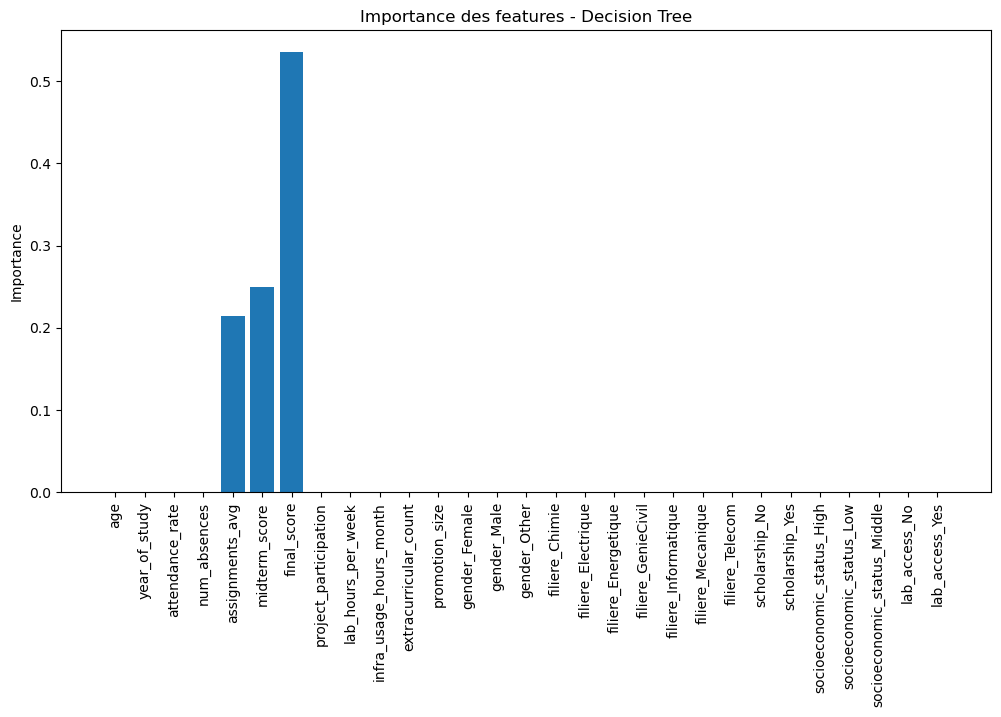

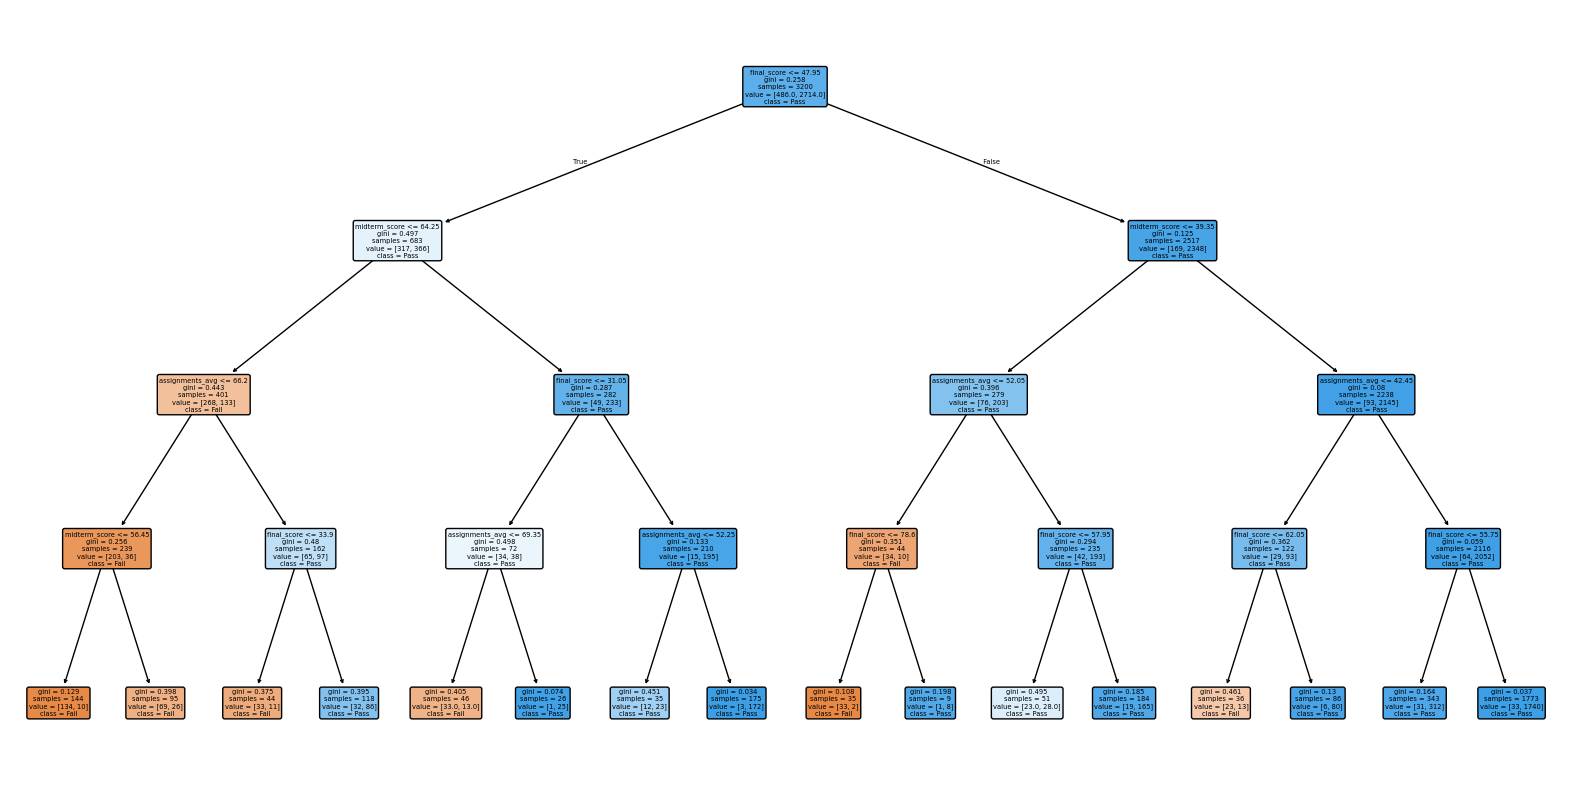

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Charger et préparer les données
# -----------------------------
df = pd.read_csv("X_train.csv")        # ton dataset
y = pd.read_csv("y_train.csv").values.ravel()  # target

# Colonnes inutiles
cols_to_drop = [ "supervisor_assigned", "classroom_allocated"]
df.drop(columns=cols_to_drop, inplace=True)

# Colonnes catégorielles à encoder
cat_cols = ["gender", "filiere", "scholarship", "socioeconomic_status", "lab_access"]
df = pd.get_dummies(df, columns=cat_cols)

# Séparer train/test
X_train, X_test, y_train, y_test = train_test_split(df.values, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# -----------------------------
# 2️⃣ Entraîner l'arbre de décision
# -----------------------------
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Prédiction et précision
y_pred = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Decision Tree:", accuracy)

# -----------------------------
# 3️⃣ Graphique - Importance des features
# -----------------------------
importance = tree_model.feature_importances_
plt.figure(figsize=(12,6))
plt.bar(range(len(importance)), importance)
plt.xticks(range(len(importance)), df.columns, rotation=90)
plt.ylabel("Importance")
plt.title("Importance des features - Decision Tree")
plt.show()

# -----------------------------
# 4️⃣ Graphique - Arbre de décision
# -----------------------------
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=df.columns, class_names=["Fail","Pass"], filled=True, rounded=True)
plt.show()


Accuracy Decision Tree : 0.8938


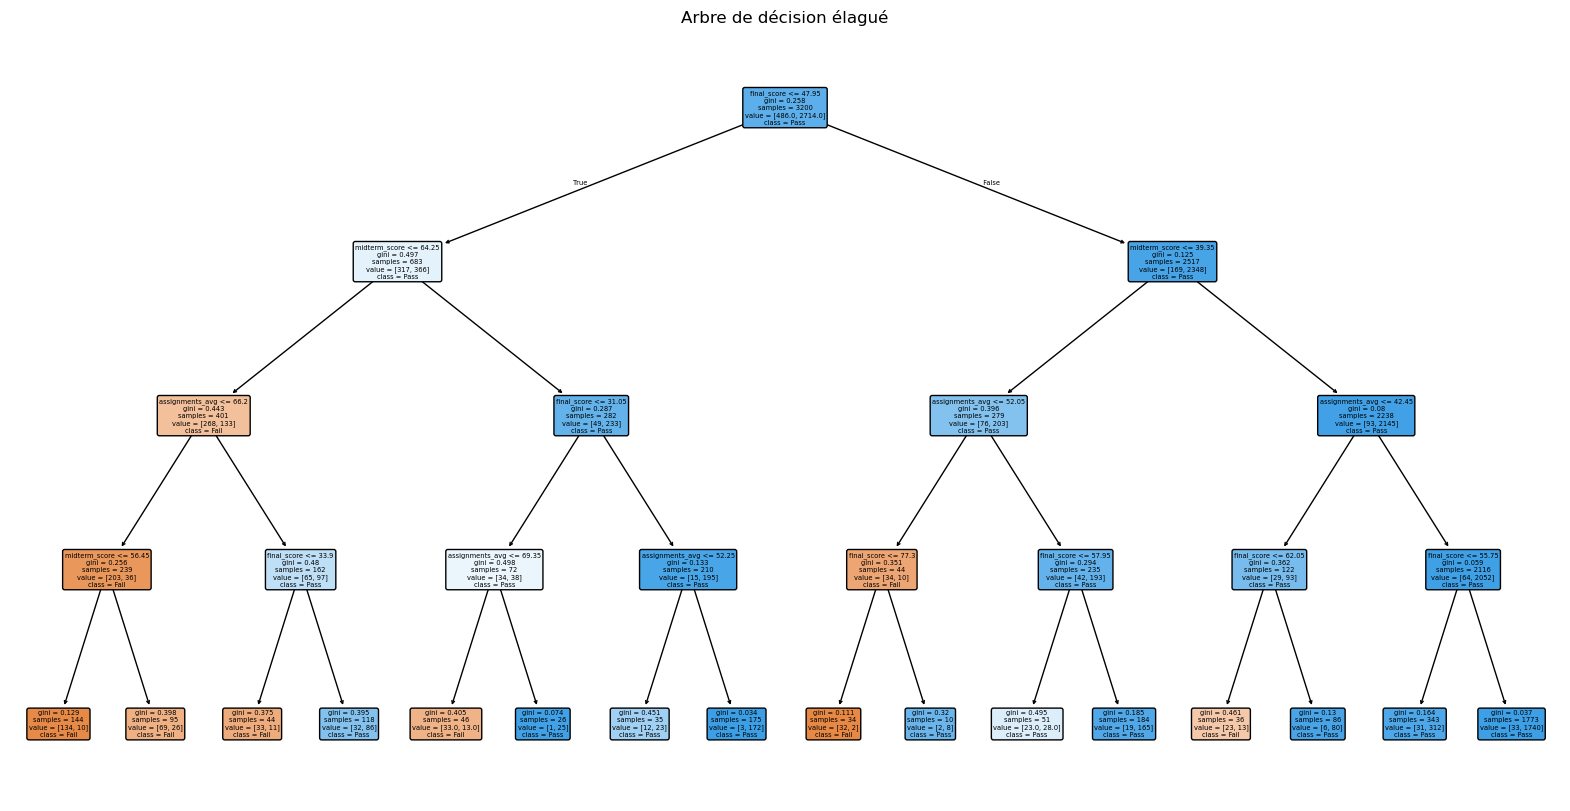


Feature importance (%) :
final_score : 53.38%
midterm_score : 25.08%
assignments_avg : 21.54%
lab_access_Yes : 0.00%
gender_Male : 0.00%


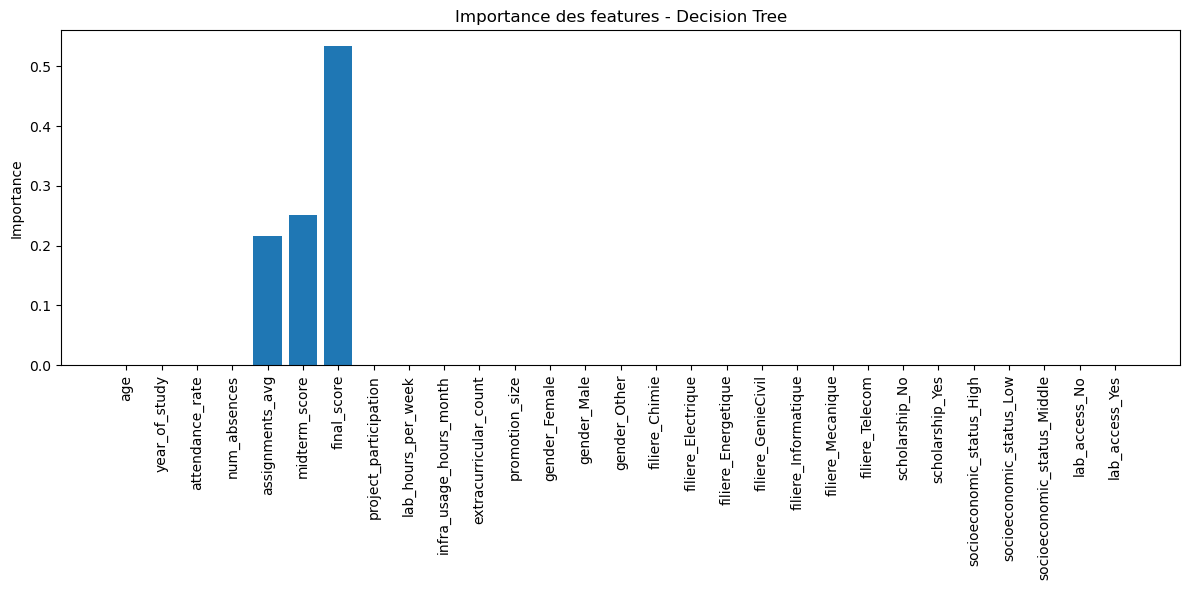


Règle principale (racine de l’arbre) :
Si final_score <= 47.95 → Classe Fail
Si final_score > 47.95 → Classe Pass

Insights sur l’arbre :
Profondeur effective de l’arbre : 4
Nombre total de feuilles : 16
100.00% des étudiants sont classés avec une seule décision


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# ------------------------------------------------
# 1️⃣ Chargement et préparation des données
# ------------------------------------------------
df = pd.read_csv("X_train.csv")
y = pd.read_csv("y_train.csv").values.ravel()

# Colonnes inutiles
cols_to_drop = ["supervisor_assigned", "classroom_allocated"]
df.drop(columns=cols_to_drop, inplace=True)

# Encodage des variables catégorielles
cat_cols = ["gender", "filiere", "scholarship", "socioeconomic_status", "lab_access"]
df = pd.get_dummies(df, columns=cat_cols)

X = df.values
feature_names = df.columns

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------
# 2️⃣ Entraînement de l’arbre de décision (élagué)
# ------------------------------------------------
tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Évaluation
y_pred = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy Decision Tree : {accuracy:.4f}")

# ------------------------------------------------
# 3️⃣ Visualisation de l’arbre (IMAGE À INSÉRER)
# ------------------------------------------------
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("Arbre de décision élagué")
plt.show()

# ------------------------------------------------
# 4️⃣ Importance des variables (Feature Importance)
# ------------------------------------------------
importances = tree_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nFeature importance (%) :")
for i in indices[:5]:
    print(f"{feature_names[i]} : {importances[i]*100:.2f}%")

plt.figure(figsize=(12,6))
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), feature_names, rotation=90)
plt.ylabel("Importance")
plt.title("Importance des features - Decision Tree")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 5️⃣ Extraction des règles principales (racine)
# ------------------------------------------------
tree_ = tree_model.tree_

root_feature_index = tree_.feature[0]
root_threshold = tree_.threshold[0]
root_feature_name = feature_names[root_feature_index]

print("\nRègle principale (racine de l’arbre) :")
print(f"Si {root_feature_name} <= {root_threshold:.2f} → Classe Fail")
print(f"Si {root_feature_name} > {root_threshold:.2f} → Classe Pass")

# ------------------------------------------------
# 6️⃣ Profondeur effective et complexité
# ------------------------------------------------
print("\nInsights sur l’arbre :")
print("Profondeur effective de l’arbre :", tree_model.get_depth())
print("Nombre total de feuilles :", tree_model.get_n_leaves())

# ------------------------------------------------
# 7️⃣ Estimation des décisions rapides
# ------------------------------------------------
# Pourcentage d’échantillons classés au niveau 1
left_count = tree_.n_node_samples[tree_.children_left[0]]
right_count = tree_.n_node_samples[tree_.children_right[0]]
total = tree_.n_node_samples[0]

quick_decision_ratio = (left_count + right_count) / total * 100

print(f"{quick_decision_ratio:.2f}% des étudiants sont classés avec une seule décision")

